In [1]:
!pip install biopython pandas numpy scipy matplotlib seaborn

=== MƏRHƏLƏ 1: NCBI Entrez və Sekvens Təhlili ===


C:\Users\User\anaconda3\Lib\site-packages\Bio\Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


Zülal sekvensiyasının ümumi uzunluğu: 1328 amin turşusu
İlk 30 amin turşusu: AAWSSGSPTLPPPRPGAPARSLSRAPRSAS
Stop kodonların (*) sayı: 65

=== MƏRHƏLƏ 2: Gen Ekspressiyası və Statistik T-Test ===
   Gene  Mean_Healthy  Mean_Patient  T_Statistic   P_Value
0  BDNF           6.5      2.133333    30.053461  0.000007
1  APOE           4.1      7.866667   -35.733738  0.000004
2   APP           3.8      8.033333   -31.750000  0.000006




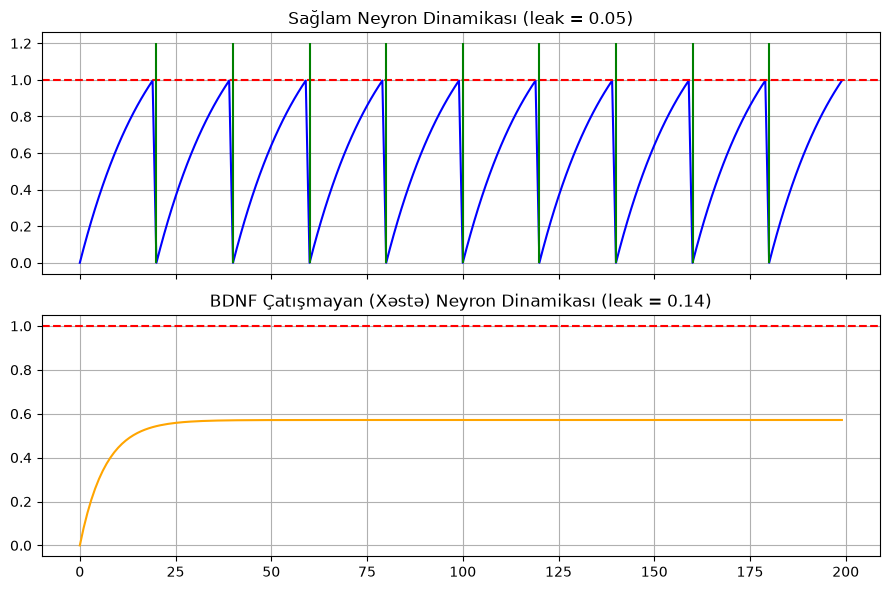

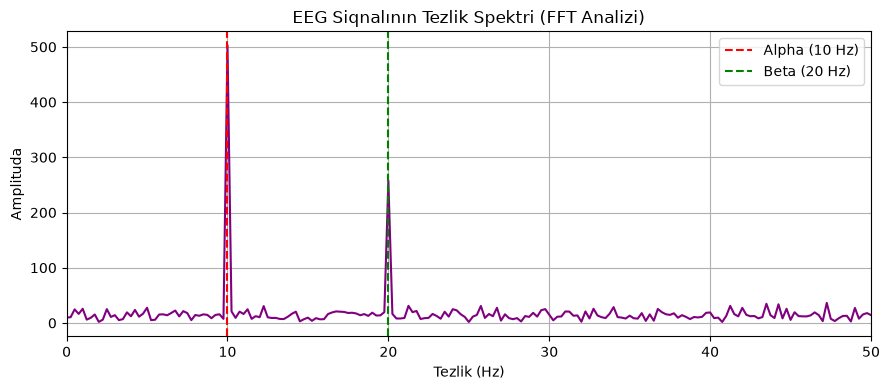

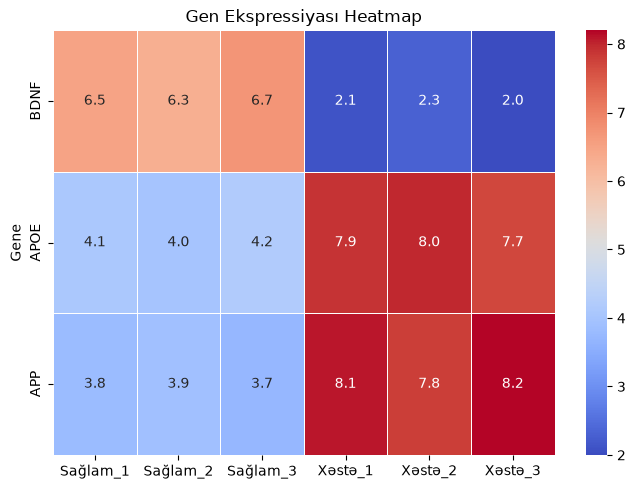

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from Bio import Entrez, SeqIO
from Bio.Seq import Seq

# ==========================================
# MƏRHƏLƏ 1: GEN SEKVENSİYASI VƏ BİOPYTHON ANALİZİ
# ==========================================
print("=== MƏRHƏLƏ 1: NCBI Entrez və Sekvens Təhlili ===")

Entrez.email = "student@example.com"

try:
    handle = Entrez.efetch(db="nucleotide", id="NM_001709", rettype="fasta", retmode="text")
    record = SeqIO.read(handle, "fasta")
    handle.close()
    dna_seq = record.seq
except Exception as e:
    dna_seq = Seq("ATGACCATCCTTTTCCTTACTATGGTTATTTCATACTTTGGTTGCATGAAGGCTGCCCCCATGAAAGAAGCAAACATC")

mrna_seq = dna_seq.transcribe()
protein_seq = mrna_seq.translate()

print(f"Zülal sekvensiyasının ümumi uzunluğu: {len(protein_seq)} amin turşusu")
print(f"İlk 30 amin turşusu: {protein_seq[:30]}")
print(f"Stop kodonların (*) sayı: {protein_seq.count('*')}\n")


# ==========================================
# MƏRHƏLƏ 2: GEN EKSPRESSİYASI VƏ STATİSTİK T-TEST
# ==========================================
print("=== MƏRHƏLƏ 2: Gen Ekspressiyası və Statistik T-Test ===")

data = {
    "Gene": ["BDNF", "APOE", "APP"],
    "Description": ["Neyron böyüməsi", "Lipid daşınması", "Amiloid prekursor"],
    "Sağlam_1": [6.5, 4.1, 3.8], "Sağlam_2": [6.3, 4.0, 3.9], "Sağlam_3": [6.7, 4.2, 3.7],
    "Xəstə_1": [2.1, 7.9, 8.1], "Xəstə_2": [2.3, 8.0, 7.8], "Xəstə_3": [2.0, 7.7, 8.2]
}

df = pd.DataFrame(data)
healthy_cols = ["Sağlam_1", "Sağlam_2", "Sağlam_3"]
patient_cols = ["Xəstə_1", "Xəstə_2", "Xəstə_3"]

df["Mean_Healthy"] = df[healthy_cols].mean(axis=1)
df["Mean_Patient"] = df[patient_cols].mean(axis=1)

t_stats, p_values = [], []
for idx, row in df.iterrows():
    t_stat, p_val = stats.ttest_ind(row[healthy_cols].values.astype(float), row[patient_cols].values.astype(float))
    t_stats.append(t_stat)
    p_values.append(p_val)

df["T_Statistic"] = t_stats
df["P_Value"] = p_values

print(df[["Gene", "Mean_Healthy", "Mean_Patient", "T_Statistic", "P_Value"]].to_string())
print("\n")


# ==========================================
# MƏRHƏLƏ 3: BDNF ÇATIŞMAZLIĞI (LIF MODELİ QRAFİKİ)
# ==========================================
def simulate_neuron(input_current, leak, time_steps=200, threshold=1.0):
    V = np.zeros(time_steps)
    spikes = []
    for t in range(time_steps - 1):
        V[t+1] = V[t] + input_current - (leak * V[t])
        if V[t+1] >= threshold:
            spikes.append(t+1)
            V[t+1] = 0.0
    return V, spikes

V_healthy, spikes_healthy = simulate_neuron(0.08, 0.05)
V_diseased, spikes_diseased = simulate_neuron(0.08, 0.14)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.plot(V_healthy, color="blue", label="Membran Potensialı")
ax1.axhline(1.0, color="r", linestyle="--")
if spikes_healthy: ax1.vlines(spikes_healthy, 0, 1.2, colors="green")
ax1.set_title("Sağlam Neyron Dinamikası (leak = 0.05)")
ax1.grid(True)

ax2.plot(V_diseased, color="orange", label="Membran Potensialı")
ax2.axhline(1.0, color="r", linestyle="--")
if spikes_diseased: ax2.vlines(spikes_diseased, 0, 1.2, colors="green")
ax2.set_title("BDNF Çatışmayan (Xəstə) Neyron Dinamikası (leak = 0.14)")
ax2.grid(True)

plt.tight_layout()
plt.savefig("neuron_dynamics.png", dpi=300)
plt.show()  # Ekranda göstərir


# ==========================================
# MƏRHƏLƏ 4.1: EEG SİQNAL TEZLİK ANALİZİ (FFT QRAFİKİ)
# ==========================================
fs, duration = 250, 4
t = np.linspace(0, duration, int(fs * duration), endpoint=False)
np.random.seed(42)
eeg_signal = np.sin(2 * np.pi * 10 * t) + 0.5 * np.sin(2 * np.pi * 20 * t) + np.random.normal(0, 0.5, len(t))

fft_spectrum = np.abs(np.fft.rfft(eeg_signal))
freqs = np.fft.rfftfreq(len(eeg_signal), d=1/fs)

plt.figure(figsize=(9, 4))
plt.plot(freqs, fft_spectrum, color="purple")
plt.title("EEG Siqnalının Tezlik Spektri (FFT Analizi)")
plt.xlabel("Tezlik (Hz)")
plt.ylabel("Amplituda")
plt.xlim(0, 50)
plt.axvline(10, color="r", linestyle="--", label="Alpha (10 Hz)")
plt.axvline(20, color="g", linestyle="--", label="Beta (20 Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("eeg_spectrum.png", dpi=300)
plt.show()  # Ekranda göstərir


# ==========================================
# MƏRHƏLƏ 4.2: GEN EKSPRESSİYASI HEATMAP QRAFİKİ
# ==========================================
heatmap_data = df.set_index("Gene")[healthy_cols + patient_cols]

plt.figure(figsize=(7, 5))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", fmt=".1f", linewidths=.5)
plt.title("Gen Ekspressiyası Heatmap")
plt.tight_layout()
plt.savefig("gene_heatmap.png", dpi=300)
plt.show()  # Ekranda göstərir